# Explicación del modelo item-to-item híbrido (PR #3)

**Proyecto Final Henry · Dynamo Consultoría & Data Solutions**

Este notebook explica, con los datos reales, el modelo de `src/models/item_based.py` y cómo se eligió y evaluó:

1. **Glosario** de los términos nuevos.
2. **La idea** en una frase y por qué la elegimos.
3. **Por qué híbrido:** lo que dicen los datos de co-compra.
4. **Similitud coseno**, con un ejemplo de juguete y uno real.
5. **Los 3 niveles del modelo** con un cliente real.
6. **Validación:** cómo elegimos los 30 días (y el error que evitamos).
7. **Resultados** contra los baselines.
8. **Limitaciones y cómo contarlo** en la demo.

> Se lee tal cual (las salidas ya están guardadas). Para re-ejecutarlo hace falta `data/processed/interactions.parquet` (se genera con `python -m src.data.make_interactions`).

## 1. Glosario

| Término | Qué significa | En nuestro modelo |
|---|---|---|
| **Item-to-item** | Recomendar a partir de un producto: "quienes compraron esto también compraron…" | Se fija en los productos, no en parecidos entre clientes |
| **Co-compra** | Que dos productos los haya comprado el mismo cliente | Si 2 clientes compraron la cama y las sábanas, esos productos tienen co-compra |
| **Vecino** | Producto "cercano" a otro según la co-compra | Las sábanas son vecinas de la cama |
| **Similitud coseno** | Número de 0 a 1 que mide qué tan seguido se compran juntos dos productos, corrigiendo por su popularidad | 1 = siempre juntos, 0 = nunca |
| **Semilla** | El producto desde el que se recomienda | Las últimas compras del cliente (máx. 5) |
| **Basado en contenido** | Recomendar por atributos del producto | Productos de la misma categoría |
| **Fallback (respaldo)** | Lo que se usa cuando el método principal no tiene datos | Popularidad de los últimos 30 días |
| **Híbrido** | Modelo que combina varios métodos | Co-compra + categoría + popularidad reciente |
| **Hiperparámetro** | Ajuste del modelo que se elige antes de entrenar | La ventana de días de popularidad (30) |
| **Validación** | Periodo separado para elegir hiperparámetros sin tocar el test | Mar–may 2018 |
| **Sobreajuste al test** | Elegir ajustes mirando el test: los resultados se ven mejor de lo que son | Lo que pasó con los "90 días" |
| **Ablación** | Quitar una parte del modelo para medir cuánto aporta | "Solo co-compra" vs "híbrido" |

## 2. La idea en una frase

> **Si el cliente es nuevo, le mostramos lo más vendido del último mes. Si ya compró antes, le mostramos lo que otros compraron junto con sus productos y, si no hay datos, lo más popular de esas categorías.**

**¿Por qué este modelo?** En Olist el 97% de los clientes compra una sola vez. Un modelo que depende del historial del cliente (como el filtrado colaborativo) casi nunca tiene datos. El item-to-item solo necesita saber qué producto le interesa al cliente, y su respaldo por popularidad cubre a los nuevos.

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import pandas as pd
import matplotlib.pyplot as plt
from src.config import INTERACTIONS_PATH
from src.evaluation.evaluate import temporal_split, ground_truth

pd.set_option("display.width", 140)
AZUL, GRIS = "#2a78d6", "#b9b8b2"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "axes.edgecolor": "#888"})

df = pd.read_parquet(INTERACTIONS_PATH)
train, test = temporal_split(df)
print(f"Train: {len(train):,} interacciones | Test: {len(test):,} interacciones")

Train: 82,414 interacciones | Test: 19,538 interacciones


## 3. Por qué híbrido: hay muy poca co-compra

In [2]:
prod_por_pedido = train.groupby("order_id")["product_id"].nunique()
prod_por_cliente = train.groupby("customer_unique_id")["product_id"].nunique()
clientes_multi = prod_por_cliente[prod_por_cliente >= 2].index
prod_con_cocompra = train[train["customer_unique_id"].isin(clientes_multi)]["product_id"].nunique()
n_prod = train["product_id"].nunique()

print(f"Pedidos con 2+ productos distintos:  {(prod_por_pedido > 1).sum():,} de {len(prod_por_pedido):,} ({(prod_por_pedido > 1).mean():.1%})")
print(f"Clientes con 2+ productos distintos: {len(clientes_multi):,} de {len(prod_por_cliente):,} ({len(clientes_multi)/len(prod_por_cliente):.1%})")
print(f"Productos con al menos una co-compra: {prod_con_cocompra:,} de {n_prod:,} ({prod_con_cocompra/n_prod:.0%})")

Pedidos con 2+ productos distintos:  2,612 de 79,399 (3.3%)
Clientes con 2+ productos distintos: 4,368 de 76,837 (5.7%)
Productos con al menos una co-compra: 6,377 de 26,716 (24%)


**Lectura:** solo 1 de cada 4 productos tiene algún "vecino" por co-compra. Si usáramos solo co-compra, para el 76% de los productos no habría nada que recomendar. Por eso el modelo tiene **tres niveles**: co-compra → misma categoría → popularidad reciente.

Este es el tipo de conexión que pide la rúbrica: *un hallazgo del EDA que justifica una decisión de modelado*.

## 4. Similitud coseno

### 4.1 Ejemplo de juguete

$$\text{similitud}(A, B) = \frac{\text{clientes que compraron A y B}}{\sqrt{\text{clientes que compraron A} \times \text{clientes que compraron B}}}$$

- **Cama:** 4 clientes la compraron. **Sábanas:** 4 clientes. **Ambas:** 3 clientes → 3 / √(4 × 4) = **0.75**
- **Cama** (4 clientes) y **cargador** de celular (100 clientes), **ambos:** 3 clientes → 3 / √(4 × 100) = **0.15**

Las dos parejas tienen 3 compradores en común, pero el cargador es muy popular: lo compra todo mundo, así que comprarlo junto con la cama no dice mucho. El coseno **corrige por popularidad** para no recomendar siempre lo más vendido.

In [3]:
from src.models.item_based import ItemToItemRecommender
modelo = ItemToItemRecommender(recent_days=30).fit(train)
cat = modelo.category_

# El producto con más vecinos, como ejemplo real
semilla = max(modelo.neighbors_, key=lambda p: len(modelo.neighbors_[p]))
vecinos = pd.DataFrame(modelo.neighbors_[semilla][:8], columns=["vecino", "similitud"])
vecinos["categoria"] = vecinos["vecino"].map(cat)
print(f"Producto semilla: {semilla[:12]}…  (categoría: {cat[semilla]})")
print(f"Tiene {len(modelo.neighbors_[semilla])} vecinos por co-compra. Los 8 más cercanos:")
vecinos.assign(vecino=vecinos["vecino"].str[:12] + "…", similitud=vecinos["similitud"].round(3))

Producto semilla: 99a4788cb248…  (categoría: bed_bath_table)
Tiene 50 vecinos por co-compra. Los 8 más cercanos:


,vecino,similitud,categoria
0,35afc973633a…,0.538,home_confort
1,f2e53dd1670f…,0.227,bed_bath_table
2,eebbed5ed3b1…,0.160,bed_bath_table
3,0a23fd10720c…,0.120,furniture_decor
4,186d7d472f06…,0.120,housewares
5,1bef08f11946…,0.120,bed_bath_table
6,2bf81ae62220…,0.120,bed_bath_table
7,3458b4c1fcbe…,0.120,bed_bath_table


**Lectura:** los vecinos con mayor similitud suelen ser de la misma categoría o de una complementaria. El modelo no conoce las categorías en este paso: lo aprende solo de quién compró qué.

## 5. Los 3 niveles con un cliente real

Para cada cliente con historial, el modelo toma sus últimas compras como **semillas** y llena el top-10 en orden:

1. **Co-compra:** vecinos de las semillas (si hay varias semillas, se suman las similitudes).
2. **Contenido:** lo más popular de la misma categoría que las semillas.
3. **Popularidad reciente:** lo más vendido de los últimos 30 días.

Nunca recomienda algo que el cliente ya compró. Buscamos un cliente del test al que el modelo **sí le acertó**:

In [4]:
truth = ground_truth(train, test)
historial = modelo.history_

def nivel_de(recs, semillas):
    vec = {nb for s in semillas for nb, _ in modelo.neighbors_.get(s, [])}
    cats = {cat.get(s) for s in semillas}
    return ["1 · co-compra" if p in vec else "2 · misma categoría" if cat.get(p) in cats
            else "3 · popularidad reciente" for p in recs]

ejemplo = None
for u in truth:
    if u in historial:
        recs = modelo.recommend(u, 10)
        if set(recs) & truth[u]:
            ejemplo = u
            if "1 · co-compra" in nivel_de(recs, historial[u][:5]):
                break

semillas = historial[ejemplo][:5]
print("Lo que el cliente compró ANTES (semillas):")
display(pd.DataFrame({"producto": [s[:12] + "…" for s in semillas], "categoria": [cat.get(s) for s in semillas]}))

recs = modelo.recommend(ejemplo, 10)
tabla = pd.DataFrame({"posición": range(1, 11), "producto": [p[:12] + "…" for p in recs],
                      "categoria": [cat.get(p, "?") for p in recs], "nivel": nivel_de(recs, semillas),
                      "¿lo compró después?": ["✅ SÍ" if p in truth[ejemplo] else "" for p in recs]})
print("Top-10 recomendado por el modelo:")
display(tabla)

Lo que el cliente compró ANTES (semillas):


,producto,categoria
0,05216a143a65…,fashion_bags_accessories


Top-10 recomendado por el modelo:


,posición,producto,categoria,nivel,¿lo compró después?
0,1,cebed2cb3b44…,fashion_bags_accessories,1 · co-compra,
1,2,d017a2151d54…,fashion_bags_accessories,2 · misma categoría,✅ SÍ
2,3,1ec486885049…,fashion_bags_accessories,2 · misma categoría,
3,4,87283a98b24f…,fashion_bags_accessories,2 · misma categoría,
4,5,ccadfeab525a…,fashion_bags_accessories,2 · misma categoría,
5,6,f177b434709e…,fashion_bags_accessories,2 · misma categoría,
6,7,6c81db10f914…,fashion_bags_accessories,2 · misma categoría,
7,8,44d097d59e84…,fashion_bags_accessories,2 · misma categoría,
8,9,77fa3381855b…,fashion_bags_accessories,2 · misma categoría,
9,10,43f88c835370…,fashion_bags_accessories,2 · misma categoría,


**Lectura:** la columna *nivel* muestra de dónde salió cada recomendación. Primero aparecen las de co-compra (si las hay), luego las de su categoría y al final las populares. La marca ✅ indica el producto que después sí compró.

### 5.1 Un cliente nuevo

In [5]:
print("Cliente sin historial → popularidad de los últimos 30 días:")
recs_nuevo = modelo.recommend("cliente_que_nunca_compro", 5)
pd.DataFrame({"posición": range(1, 6), "producto": [p[:12] + "…" for p in recs_nuevo],
              "categoria": [cat.get(p, "?") for p in recs_nuevo]})

Cliente sin historial → popularidad de los últimos 30 días:


,posición,producto,categoria
0,1,53b36df67ebb…,watches_gifts
1,2,aca2eb7d00ea…,furniture_decor
2,3,89b121bee266…,computers_accessories
3,4,3dd2a17168ec…,computers_accessories
4,5,3fbc0ef74595…,health_beauty


## 6. Validación: cómo elegimos los 30 días

El modelo tiene un **hiperparámetro** clave: cuántos días hacia atrás contar para la popularidad. Lo correcto es elegirlo en un **periodo de validación** separado del test:

```
2016 ──────────── train validación ────────────┤ validación ├┤──── test ────┤
                                          mar-2018      jun-2018      sep-2018
```

- Se entrena con compras antes de **mar-2018** y se mide en **mar–may 2018** → se elige la ventana.
- Recién entonces se evalúa en el **test** (jun–ago 2018), una sola vez.

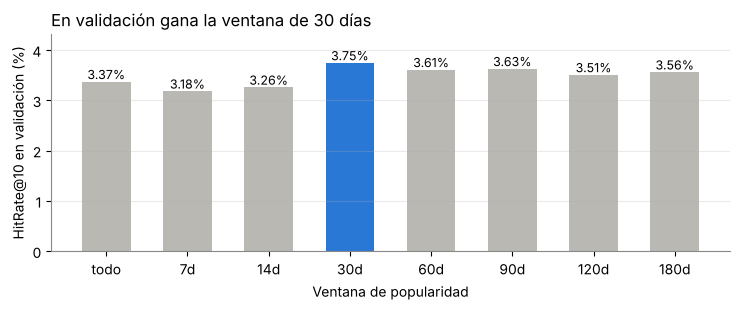

In [6]:
val = pd.read_csv(ROOT / "reports" / "validation_recent_window.csv")
val["ventana"] = val["recent_days"].apply(lambda d: "todo" if pd.isna(d) else f"{int(d)}d")
val["hit"] = val["hit_rate@10_val"] * 100
mejor = val.loc[val["recent_days"].notna(), "hit"].idxmax()

fig, ax = plt.subplots(figsize=(7.5, 3.2))
colores = [AZUL if i == mejor else GRIS for i in val.index]
ax.bar(val["ventana"], val["hit"], color=colores, width=0.6)
for x, v in zip(val["ventana"], val["hit"]):
    ax.text(x, v + 0.05, f"{v:.2f}%", ha="center", fontsize=9)
ax.set_ylim(0, val["hit"].max() * 1.15)
ax.grid(axis="x", visible=False)
ax.set_xlabel("Ventana de popularidad")
ax.set_ylabel("HitRate@10 en validación (%)")
ax.set_title("En validación gana la ventana de 30 días", loc="left")
plt.tight_layout(); plt.show()

**El error que evitamos.** Primero probamos las ventanas directamente en el test y 90 días parecía mejorar **+51%**. Pero elegir mirando el test es como ver las respuestas del examen antes de presentarlo: el resultado se ve mejor de lo que es (**sobreajuste al test**). Al elegir en validación:

- **30 días** fue la mejor ventana en **dos** periodos de validación distintos (dic–feb y mar–may).
- En el test, 30 días da una mejora **real de +14%** sobre el baseline (y el híbrido completo, +15%).

También se decidió en validación **no** filtrar el nivel de categoría por precio parecido: empeoraba el acierto.

## 7. Resultados en el test

In [7]:
res = pd.read_csv(ROOT / "reports" / "model_comparison.csv")
k10 = res[res["k"] == 10].pivot(index="model", columns="segment", values=["hit_rate@k", "coverage"])
orden = ["pop_global (baseline)", "pop_categoria", "pop_reciente_30d", "item2item_solo_cocompra", "item2item_hibrido"]
k10 = k10.loc[orden]
tabla = pd.DataFrame({
    "HitRate@10 todos (%)": (k10[("hit_rate@k", "all")] * 100).round(2),
    "HitRate@10 con historial (%)": (k10[("hit_rate@k", "warm")] * 100).round(2),
    "Cobertura del catálogo (%)": (k10[("coverage", "all")] * 100).round(2),
    "Mejora vs baseline (todos)": ((k10[("hit_rate@k", "all")] / k10[("hit_rate@k", "all")].iloc[0] - 1) * 100).round(0).astype(int).astype(str) + "%",
})
tabla

,HitRate@10 todos (%),HitRate@10 con historial (%),Cobertura del catálogo (%),Mejora vs baseline (todos)
model,,,,
pop_global (baseline),1.19,1.03,0.04,0%
pop_categoria,1.21,2.07,1.67,2%
pop_reciente_30d,1.35,1.03,0.04,14%
item2item_solo_cocompra,1.35,1.03,1.98,14%
item2item_hibrido,1.37,2.07,3.29,15%


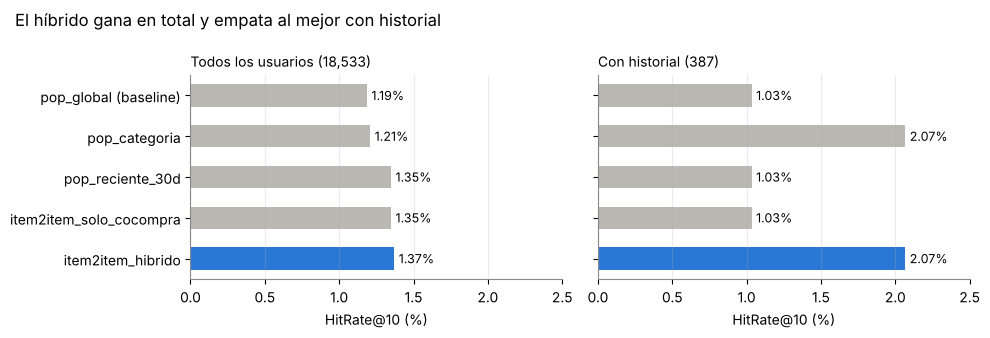

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4), sharey=True, sharex=True)
for ax, seg, titulo in [(axes[0], "all", "Todos los usuarios (18,533)"),
                        (axes[1], "warm", "Con historial (387)")]:
    vals = k10[("hit_rate@k", seg)] * 100
    colores = [AZUL if m == "item2item_hibrido" else GRIS for m in vals.index]
    ax.barh(vals.index, vals.values, color=colores, height=0.55)
    for i, v in enumerate(vals.values):
        ax.text(v + 0.03, i, f"{v:.2f}%", va="center", fontsize=9)
    ax.set_title(titulo, loc="left", fontsize=10)
    ax.set_xlabel("HitRate@10 (%)")
    ax.grid(axis="y", visible=False)
    ax.set_xlim(0, 2.5)
axes[0].invert_yaxis()
fig.suptitle("El híbrido gana en total y empata al mejor con historial", x=0.02, ha="left")
plt.tight_layout(); plt.show()

**Cómo leer los resultados:**

- **Todos los usuarios:** el híbrido pasa de 1.19% a **1.37% (+15%)**. Casi toda la mejora viene de usar popularidad *reciente* en lugar de histórica, porque el 98% son clientes nuevos.
- **Con historial:** el híbrido **duplica** al baseline (1.03% → 2.07%) y empata con la popularidad por categoría.
- **Ablación:** "solo co-compra" no mejora a los clientes con historial (1.03%). El aporte viene de **combinar** co-compra con categoría. Confirma la decisión de hacerlo híbrido.
- **Cobertura:** el híbrido recomienda el **3.3%** del catálogo contra el 0.04% del baseline (unos 80 veces más productos distintos). Es mejor para el negocio: no se limita a empujar siempre los mismos 10 productos.

**Por qué elegimos el híbrido:** es el mejor o empata al mejor en las dos poblaciones, tiene la mayor cobertura y es fácil de explicar.

## 8. Limitaciones y cómo contarlo

**Limitaciones** (mencionarlas suma puntos: la rúbrica pide discutir trade-offs):

- Solo **387** clientes con historial en el test: las diferencias en ese segmento pueden ser ruido.
- El acierto exige el **producto exacto**; recomendar otra funda de celular cuenta como fallo.
- Olist no trae **qué producto está viendo** el cliente. En una tienda real, ese sería la semilla y el item-to-item serviría también para los clientes nuevos.
- Una sola partición de test; se podría repetir con varias ventanas de tiempo.

### Cómo contarlo en la demo (30 segundos)

> "Nuestro modelo es un item-to-item híbrido. Para clientes nuevos, que son el 98%, recomienda lo más vendido del último mes. Para clientes con historial, recomienda lo que otros compraron junto con sus productos y, si no hay datos, lo popular de su categoría. Lo hicimos híbrido porque solo el 24% de los productos tiene co-compras. Elegimos la ventana de 30 días en un periodo de validación para no sobreajustar al test. Resultado: +15% sobre el baseline en general, el doble en clientes con historial, y recomienda 80 veces más productos distintos."

### Preguntas para autoevaluarte

1. ¿Qué es la similitud coseno y por qué no basta con contar co-compras? → 4.1
2. ¿Por qué el modelo tiene tres niveles? → 3
3. ¿Qué es una semilla y de dónde sale? → 5
4. ¿Por qué elegimos 30 días y no 90? → 6
5. ¿De dónde viene la mayor parte de la mejora del +15%? → 7
6. ¿Qué demostró la ablación "solo co-compra"? → 7
7. ¿Qué limitación tiene usar Olist para un item-to-item? → 8